# Análisis Exploratorio de Datos (EDA) y Preparación de Datos

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import openpyxl

# Configuración inicial para los gráficos
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga de Datos
Los datos están en formato CSV separados por punto y coma (`;`). Cargaremos tanto los vinos rojos como los blancos y los uniremos en un solo DataFrame.

In [18]:
# Cargar datos
df_red = pd.read_csv('../datos/crudos/winequality-red.csv', sep=';')
df_white = pd.read_csv('../datos/crudos/winequality-white.csv', sep=';')

# Agregar columna para identificar el tipo de vino
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Unir ambos datasets
df = pd.concat([df_red, df_white], ignore_index=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 2. Exploración Inicial

In [19]:
# Información general del dataset
print("Información del Dataset:")
df.info()

print("\n\nEstadísticas Descriptivas:")
display(df.describe())

Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


Estadísticas Descriptivas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


## 3. Valores Nulos

In [20]:
# Comprobar valores nulos
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

## 4. Visualización Básica

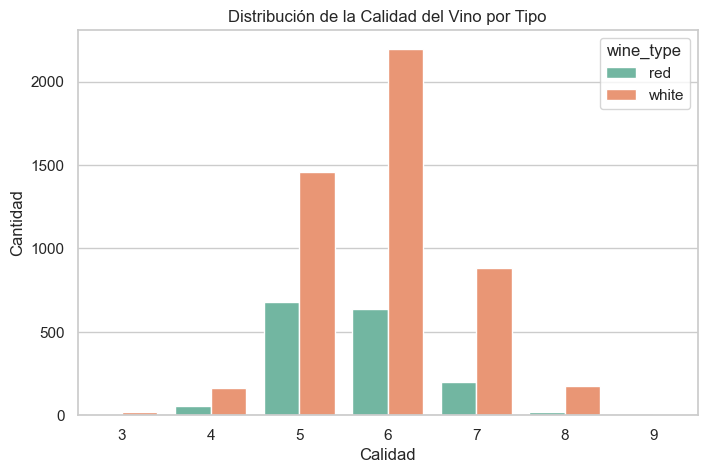

In [21]:
# Distribución de la calidad del vino
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='quality', hue='wine_type', palette='Set2')
plt.title('Distribución de la Calidad del Vino por Tipo')
plt.xlabel('Calidad')
plt.ylabel('Cantidad')
plt.show()

# Análisis Comparativo por Tipo de Vino

A partir de los datos limpios almacenados en `datos/procesados/winequality_cleaned.csv`, hemos extraído insights clave sobre las diferencias entre el vino tinto y el vino blanco. 

A continuación presento las gráficas generadas y su interpretación:

## 1. Distribución de Calidad

![Distribución de la Calidad por Tipo de Vino](/Users/federicopinzonrubiano/.gemini/antigravity/brain/6ff78b12-f3c5-445e-96d6-9303edc4cfe1/wine_quality_distribution.png)

> [!NOTE]
> **Interpretación**: 
> Este gráfico de violín muestra cómo se distribuyen las calificaciones para ambos tipos de vino. Como podemos ver, ambas curvas son muy gruesas en la calificación de **6**, indicando que la mayoría de los vinos (tanto blancos como tintos) reciben una puntuación estándar o promedio. Sin embargo, el vino blanco tiene una concentración ligeramente más alta en puntuaciones de **7** y **8** (las partes superiores son más gruesas), sugiriendo que hay proporcionalmente más vinos blancos de alta calidad en este dataset en comparación con el tinto.

## 2. Diferencias Químicas Clave

![Comparativa de Densidades Químicas](/Users/federicopinzonrubiano/.gemini/antigravity/brain/6ff78b12-f3c5-445e-96d6-9303edc4cfe1/wine_chemical_density.png)

> [!TIP]
> **Interpretación**:
> * **Alcohol**: Ambos vinos tienen una concentración de alcohol con distribución muy similar (el pico principal para ambos está entre 9% y 10%). Las densidades se superponen casi por completo.
> * **Acidez Volátil**: Aquí hay una **diferencia drástica**. El vino blanco tiene niveles de acidez volátil muchísimo más bajos y concentrados que el vino tinto. Dado que el diccionario de datos indica que altos niveles de este ácido pueden dar sabor a vinagre, esto confirma que los vinos blancos se producen con controles de acidez volátil mucho más estrictos para mantener su perfil fresco, mientras que los vinos tintos, por su naturaleza tánica y robusta, tienden a poseer niveles más altos.

## Conclusión

El análisis revela que, aunque ambos tipos de vino comparten distribuciones similares de alcohol y calificaciones promedio (6), **químicamente son distintos**. La gran diferencia en la **acidez volátil** marca los perfiles de sabor de cada uno, justificando por qué debían analizarse como dos grupos separados tras realizar el Data Wrangling.
